# ClickHouse API Tutorial — Session Purchase Forecasting (Oct 2019)

## Objective (Learn ClickHouse in ~60 minutes)
We build a small analytics platform using **ClickHouse** as the core OLAP engine.

- **Dataset**: `data/2019-Oct.csv` (event log)
- **Hypothesis**: Using the **first N events** in a `user_session` (start with **N=5**), we can predict whether the session will have a **purchase later**.
- **Label**: `has_purchase_in_session` ∈ {0,1}

## What this notebook does
- Creates a robust raw→typed ingestion pipeline in ClickHouse (handles `event_time` strings like `... UTC`)
- Runs OLAP/funnel analytics queries
- Builds a physical ML training table in ClickHouse: `training_sessions_n5`
- Creates summary tables for Grafana

Next notebook: `clickhouse.example.ipynb` trains Logistic Regression + XGBoost and writes predictions back into ClickHouse.


## Step 1/9 — Setup + connect

**What this does**: Imports libraries, points Python at `/app` (so we can import helper code), and opens a ClickHouse connection.

**Why we do it**: Every step below is driven by SQL. If we can connect and run a trivial query, we know the environment is healthy.

**What to look for in the output (and how to interpret it)**:
- **ClickHouse version**: confirms you’re connected to the server you think you are.
- **Database**: should be `ecomm` (unless you changed `CLICKHOUSE_DB`). If it’s different, later tables may appear “missing”.

**Common issues + fixes**:
- **Connection refused / timeout**: start the container: `docker compose up -d clickhouse`.
- **Wrong database**: check `CLICKHOUSE_DB` env var and defaults in `clickhouse_utils.py`.


In [ ]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path("/app")))


import pandas as pd
import plotly.express as px

from clickhouse_utils import get_client, print_kv, ch_df

print("Step 1/9: Setup + connect")

DATA_PATH = Path("/app/data/2019-Oct.csv")
print_kv("Dataset path", DATA_PATH)

client = get_client()
print_kv("ClickHouse version", client.execute("SELECT version()"))
print_kv("Database", client.execute("SELECT currentDatabase()"))

Step 1/9: Setup + connect
Dataset path: /app/data/2019-Oct.csv
ClickHouse version: [('26.3.9.8',)]
Database: [('ecomm',)]


## Step 3/9 — Confirm ingestion happened (fast check)

**What this does**: Verifies that the dataset was ingested into ClickHouse by checking row counts in `events_raw` and `events_typed`.

**Why we do it**: The CSV is large; ingestion is intentionally done by `./docker_ingest.sh` (fast, reproducible) instead of loading gigabytes into pandas. This check prevents “mystery failures” later.

**What to look for in the output (and how to interpret it)**:
- **Both counts > 0**: ingestion actually happened.
- **Counts match**: the raw→typed materialized view is working and successfully parsed timestamps.

**Common issues + fixes**:
- **Table not found / zero rows**: run `./docker_ingest.sh` from project root, then rerun from Step 1.
- **Raw > typed**: some timestamps failed parsing. Re-check the MV logic (timestamp parsing + `UTC` string cleanup) in `docker_ingest.sh`.


In [ ]:
print("Step 3/9: Verify data is already ingested (fast)")

# For a linear, reproducible run we ingest with ClickHouse directly:
#   ./docker_ingest.sh
# This keeps the notebook fast and avoids loading a multi-GB CSV in Python.

raw_rows = client.execute("SELECT count() FROM events_raw")[0][0]
typed_rows = client.execute("SELECT count() FROM events_typed")[0][0]
print_kv("events_raw rows", raw_rows)
print_kv("events_typed rows", typed_rows)

if raw_rows == 0 or typed_rows == 0:
    raise RuntimeError(
        "Data not ingested yet. Run: ./docker_ingest.sh (from project root), then rerun this notebook."
    )

print("Data is ready. Continuing with analytics + feature engineering...")


Step 3/9: Verify data is already ingested (fast)
events_raw rows: 42448764
events_typed rows: 42448764
Data is ready. Continuing with analytics + feature engineering...


## Step 4/9 — Sanity check the typed table

**What this does**: Runs two quick queries against `events_typed` to validate the dataset (timestamp range, row counts, and which `event_type`s exist).

**Why we do it**: If `events_typed` is wrong, every downstream table (labels, features, training data) will be wrong too. This is the cheapest place to catch ingestion/typing mistakes.

**What to look for in the output (and how to interpret it)**:
- **`min_time` / `max_time`**: should span the expected month (Oct 2019).
- **`rows`**: should be large (tens of millions) but finite.
- **`users` / `sessions`**: should be large; if `sessions` is tiny or 0, ingestion failed.
- **Event types**: you should see the expected set (e.g., `view`, `cart`, `purchase`). If an event type is missing, any feature depending on it will become constant (often all zeros).

**ClickHouse notes**:
- `uniqExact(x)` is an **exact** distinct count (accurate, sometimes slower than approximate `uniq*`).

**Common issues + fixes**:
- **Missing/empty tables**: rerun `./docker_ingest.sh`.
- **Raw rows ≠ typed rows**: timestamp parsing failed for some rows; check the raw→typed materialized view logic in `docker_ingest.sh`.


In [ ]:
print("Step 4/9: Minimal sanity checks on typed data")

# Query 1 (`q_basic`): Returns the earliest/latest event timestamp, total event rows, distinct users, and distinct sessions from `events_typed`.

q_basic = """
SELECT
  min(event_time_dt) AS min_time,
  max(event_time_dt) AS max_time,
  count() AS rows,
  uniqExact(user_id) AS users,
  uniqExact(user_session) AS sessions
FROM events_typed
"""
print(ch_df(client, q_basic, ["min_time","max_time","rows","users","sessions"]))

# Query 2 (`q_event_types`): Counts how many rows exist per `event_type` and sorts them descending so the most common event types appear first.

q_event_types = """
SELECT event_type, count() AS n
FROM events_typed
GROUP BY event_type
ORDER BY n DESC
"""
print(ch_df(client, q_event_types, ["event_type","n"]).head(10))

Step 4/9: Minimal sanity checks on typed data
                   min_time                  max_time      rows    users  \
0 2019-10-01 00:00:00+00:00 2019-10-31 23:59:59+00:00  42448764  3022290   

   sessions  
0   9244422  
  event_type         n
0       view  40779399
1       cart    926516
2   purchase    742849


## Step 5/9 — Analytics: `hourly_funnel` + funnel charts + top categories

**What this does**:
1. Creates **`hourly_funnel`** (`SummingMergeTree`) and **`mv_hourly_funnel`**, then **backfills** from `events_typed` (MVs only see *new* inserts; backfill loads history).
2. Builds the **daily funnel line chart** by reading **`hourly_funnel`** and rolling up with `toDate(event_hour)` + `sum(...)` (same metrics as before, but **one stored source** Grafana can query too).
3. Runs **top categories by revenue** directly on **`events_typed`** (needs `category_code` / `price` — not in the hourly rollup).

**Why we do it**: Avoid maintaining the same funnel counts in two places. The notebook and Grafana share **`hourly_funnel`**.

**What to look for**:
- **`hourly_funnel` row count** roughly matches distinct hours in the month.
- **Daily views > carts > purchases**; **`purchase_per_view`** is a small fraction.
- **Top categories** look plausible.

**ClickHouse notes**:
- `countIf` / `sumIf` in the MV definition; `SummingMergeTree` stores **additive** counters. When aggregating further (daily rollup), use **`sum(views)`**, **`sum(carts)`**, **`sum(purchases)`** over hours.

**Common issues + fixes**:
- **Empty `hourly_funnel`**: confirm `events_typed` has rows (Steps 3–4), then rerun this cell.
- **All zeros in charts**: ingestion or MV wiring issue.


Step 5/9: hourly_funnel (MV + backfill) + daily funnel from rollup + top categories
hourly_funnel rows: [(744,)]
Preview hourly_funnel:
           event_hour  views  carts  purchases
0 2019-10-01 00:00:00   1070      3         10
1 2019-10-01 01:00:00    121      0          0
2 2019-10-01 02:00:00  22326    244        316
3 2019-10-01 03:00:00  47951    613        845
4 2019-10-01 04:00:00  53390    879       1021
   event_date    views  carts  purchases  purchase_per_view
0  2019-10-01  1208280  16658      19307           0.015979
1  2019-10-02  1154591  17268      19469           0.016862
2  2019-10-03  1088725  19323      19255           0.017686
3  2019-10-04  1346320  43829      27041           0.020085
4  2019-10-05  1271348  35497      23494           0.018480


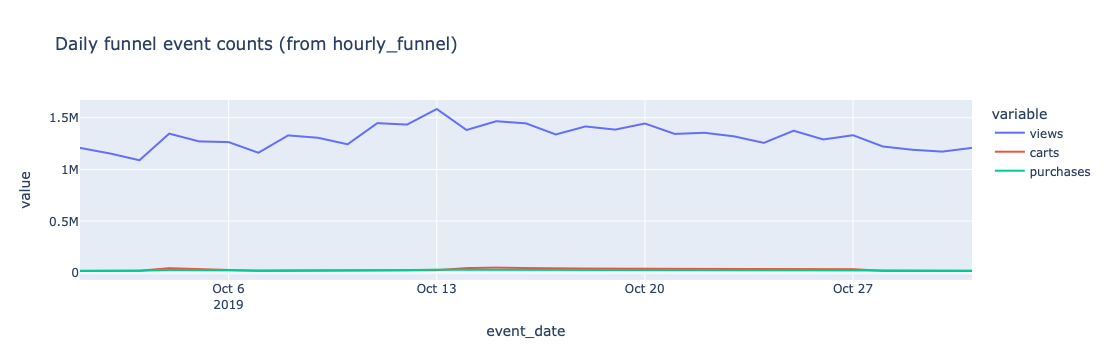

                      category_code  purchases       revenue
0            electronics.smartphone     338018  1.570496e+08
1                              None     173425  2.292494e+07
2                computers.notebook      15590  8.979887e+06
3              electronics.video.tv      21565  8.423408e+06
4                electronics.clocks      17906  4.818305e+06
5         appliances.kitchen.washer      16148  4.658647e+06
6  appliances.kitchen.refrigerators      11218  3.830077e+06
7       electronics.audio.headphone      30503  3.539127e+06
8     appliances.environment.vacuum      12378  1.716425e+06
9                electronics.tablet       5603  1.610974e+06


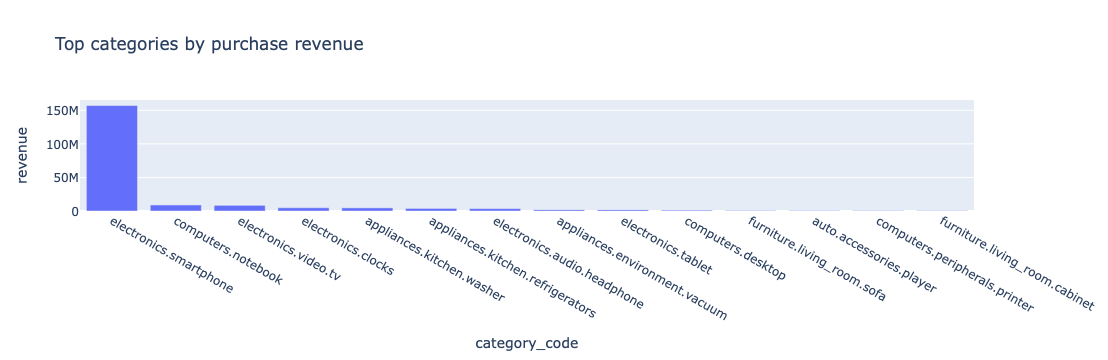

In [ ]:
print("Step 5/9: hourly_funnel (MV + backfill) + daily funnel from rollup + top categories")

HOURLY_FUNNEL_SELECT = """
SELECT
  toStartOfHour(event_time_dt) AS event_hour,
  countIf(event_type = 'view') AS views,
  countIf(event_type = 'cart') AS carts,
  countIf(event_type = 'purchase') AS purchases
FROM events_typed
GROUP BY event_hour
"""

client.execute("DROP TABLE IF EXISTS hourly_funnel")
client.execute(
    """
    CREATE TABLE hourly_funnel
    (
      event_hour DateTime,
      views UInt64,
      carts UInt64,
      purchases UInt64
    )
    ENGINE = SummingMergeTree
    ORDER BY (event_hour)
    """
)

client.execute("DROP VIEW IF EXISTS mv_hourly_funnel")
client.execute(
    f"""
    CREATE MATERIALIZED VIEW mv_hourly_funnel
    TO hourly_funnel
    AS
    {HOURLY_FUNNEL_SELECT}
    """
)

client.execute("TRUNCATE TABLE hourly_funnel")
client.execute(f"INSERT INTO hourly_funnel {HOURLY_FUNNEL_SELECT}")

print_kv("hourly_funnel rows", client.execute("SELECT count() FROM hourly_funnel"))
print("Preview hourly_funnel:")
print(ch_df(client, "SELECT * FROM hourly_funnel ORDER BY event_hour LIMIT 5", ["event_hour", "views", "carts", "purchases"]))

q_funnel_daily = """
SELECT
  event_date,
  views,
  carts,
  purchases,
  purchases / nullIf(views, 0) AS purchase_per_view
FROM (
  SELECT
    toDate(event_hour) AS event_date,
    sum(views) AS views,
    sum(carts) AS carts,
    sum(purchases) AS purchases
  FROM hourly_funnel
  GROUP BY event_date
)
ORDER BY event_date
LIMIT 31
"""

df_funnel = ch_df(
    client,
    q_funnel_daily,
    ["event_date", "views", "carts", "purchases", "purchase_per_view"],
)
print(df_funnel.head(5))

fig = px.line(df_funnel, x="event_date", y=["views", "carts", "purchases"], title="Daily funnel event counts (from hourly_funnel)")
fig.show()

# Top categories still need event-level columns
q_top_cat = """
SELECT
  category_code,
  countIf(event_type = 'purchase') AS purchases,
  sumIf(price, event_type = 'purchase') AS revenue
FROM events_typed
GROUP BY category_code
ORDER BY revenue DESC
LIMIT 15
"""

df_top_cat = ch_df(client, q_top_cat, ["category_code", "purchases", "revenue"])
print(df_top_cat.head(10))

fig2 = px.bar(df_top_cat, x="category_code", y="revenue", title="Top categories by purchase revenue")
fig2.show()